# Introduction to Mathematical Modelling

**by Dr Kamil Erguler**  
Climate and One Health Group  
CARE-C - The Cyprus Institute

---

[Previous (Selection)](https://veclim.com/tutorials-viewer/localfile/MathMod/T04_IMM_selection.ipynb) --- [Index](https://veclim.com/tutorials-viewer/localfile/MathMod/T00_IMM_intro.ipynb) --- Next (Chapter 2)


## Thermal performance curves — Part 3

So far — well, at least since our D&D adventure — we have worked with deterministic models accompanied by well-behaved, normally distributed noise. In the next chapter, we will examine how to build genuinely stochastic models whose outcomes may be too complex to describe using standard probability distributions.

To understand the behaviour of such a model under a particular parameter configuration, we may need to simulate it repeatedly and examine the resulting realisations. This process can become so cumbersome and computationally demanding that evaluating the likelihood of the observations is impractical.

Inference is still possible under these circumstances, although it requires somewhat more advanced techniques. Here, we will introduce a basic form of **likelihood-free inference**, in which we assess model fit by comparing simulated data with the observations.

One method that is simple enough to implement here is **Approximate Bayesian Computation with Sequential Monte Carlo**, or **ABC–SMC** [<a href="https://doi.org/10.1098/rsif.2008.0172" target="_blank" rel="noopener noreferrer">link</a>].

Let us begin with the observations and models from the previous tutorial. This time, however, we will remove the likelihood functions: in this final tutorial on joint model and parameter inference, we will rely entirely on simulations.

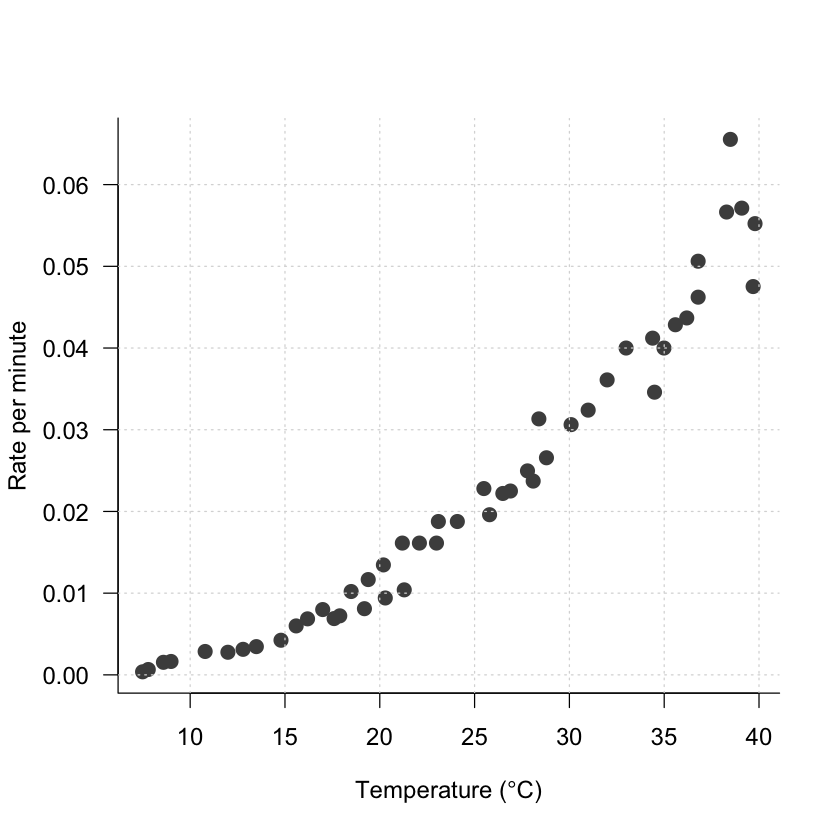

In [1]:
# S1 Data - Corkrey R, McMeekin TA, Bowman JP, Ratkowsky DA, Olley J, Ross T (2016) 
# The Biokinetic Spectrum for Temperature. PLoS ONE 11(4): e0153343. 
# https://doi.org/10.1371/journal.pone.0153343

Corkrey <- read.csv("https://doi.org/10.1371/journal.pone.0153343.s004")

d <- Corkrey[
  (Corkrey$binomial.name == "Escherichia coli") &
    (Corkrey$strain.code == 547) &
    (Corkrey$T.C <= 40),
]
d <- d[order(d$T.C), ]

par(bg = "white", cex = 1.2)

plot(d$T.C, d$rate.per.minute,
  type = "p", pch = 16, cex = 1.4,
  col = "grey30", las = 1, bty = "l",
  xlab = expression("Temperature ("*degree*C*")"),
  ylab = "Rate per minute",
  xlim = range(d$T.C),
  ylim = range(d$rate.per.minute))

grid(col = "grey85", lty = "dotted")

In [2]:
models <- list()

models[["linear"]] <- list(
  "sim" = function(T, param) {
    pr_a <- param["pr_a"]
    pr_b <- param["pr_b"]
    pr_sigma <- param["sigma"]

    expected <- pr_a * T + pr_b

    rnorm(n = length(T), mean = expected, sd = pr_sigma)
  },

  "sample.prior" = function() {
    c(pr_a = runif(1, 0, 0.005),
      pr_b = runif(1, -0.10, 0.10),
      sigma = runif(1, 0.002, 0.05))
  },

  "log.prior" = function(param) {
    pr_a <- param["pr_a"]
    pr_b <- param["pr_b"]
    sigma <- param["sigma"]

    if (any(!is.finite(c(pr_a, pr_b, sigma))) ||
        pr_a < 0 || pr_a > 0.005 ||
        pr_b < -0.10 || pr_b > 0.10 ||
        sigma < 0.002 || sigma > 0.05) {
      return(-Inf)
    }

    -log(0.005 - 0) - log(0.10 - (-0.10)) - log(0.05 - 0.002)
  },

  "proposal.sd" = c(pr_a = 0.00015, pr_b = 0.006, sigma = 0.0015)
)

models[["exponential"]] <- list(
  "sim" = function(T, param) {
    pr_a <- param["pr_a"]
    pr_b <- param["pr_b"]
    pr_c <- param["pr_c"]
    pr_sigma <- param["sigma"]

    expected <- pr_a * exp(pr_b * (T - pr_c))

    rnorm(n = length(T), mean = expected, sd = pr_sigma)
  },

  "sample.prior" = function() {
    c(pr_a = runif(1, 0, 0.10),
      pr_b = runif(1, -0.10, 0.20),
      pr_c = runif(1, 0, 30),
      sigma = runif(1, 0.002, 0.05))
  },

  "log.prior" = function(param) {
    pr_a <- param["pr_a"]
    pr_b <- param["pr_b"]
    pr_c <- param["pr_c"]
    sigma <- param["sigma"]

    if (any(!is.finite(c(pr_a, pr_b, pr_c, sigma))) ||
        pr_a < 0.0 || pr_a > 0.10 ||
        pr_b < -0.10 || pr_b > 0.20 ||
        pr_c < 0 || pr_c > 30 ||
        sigma < 0.002 || sigma > 0.05) {
      return(-Inf)
    }

    -log(0.10 - 0.0) - log(0.20 - (-0.10)) - log(30 - 0) - log(0.05 - 0.002)
  },

  "proposal.sd" = c(pr_a = 0.0015, pr_b = 0.005, pr_c = 0.75, sigma = 0.0015)
)

models[["briere"]] <- list(
  "sim" = function(T, param) {
    pr_a <- param["pr_a"]
    pr_b <- param["pr_b"]      # lower thermal limit
    pr_c <- param["pr_c"]      # upper thermal limit
    pr_sigma <- param["sigma"]

    expected <- numeric(length(T))

    inside <- T > pr_b & T < pr_c

    expected[inside] <- (pr_a * T[inside] * (T[inside] - pr_b) * sqrt(pr_c - T[inside]))

    rnorm(n = length(T), mean = expected, sd = pr_sigma)
  },

  "sample.prior" = function() {
    c(pr_a = runif(1, 0, 5e-5),
      pr_b = runif(1, 0, 15),
      pr_c = runif(1, 35, 55),
      sigma = runif(1, 0.002, 0.05))
  },

  "log.prior" = function(param) {
    pr_a <- param["pr_a"]
    pr_b <- param["pr_b"]
    pr_c <- param["pr_c"]
    sigma <- param["sigma"]

    if (any(!is.finite(c(pr_a, pr_b, pr_c, sigma))) ||
        pr_a < 0 || pr_a > 5e-5 ||
        pr_b < 0 || pr_b > 15 ||
        pr_c < 35 || pr_c > 55 ||
        sigma < 0.002 || sigma > 0.05) {
      return(-Inf)
    }

    -log(5e-5 - 0) - log(15 - 0) - log(55 - 35) - log(0.05 - 0.002)
  },

  "proposal.sd" = c(pr_a = 1.5e-6, pr_b = 0.5, pr_c = 0.5, sigma = 0.0015)
)

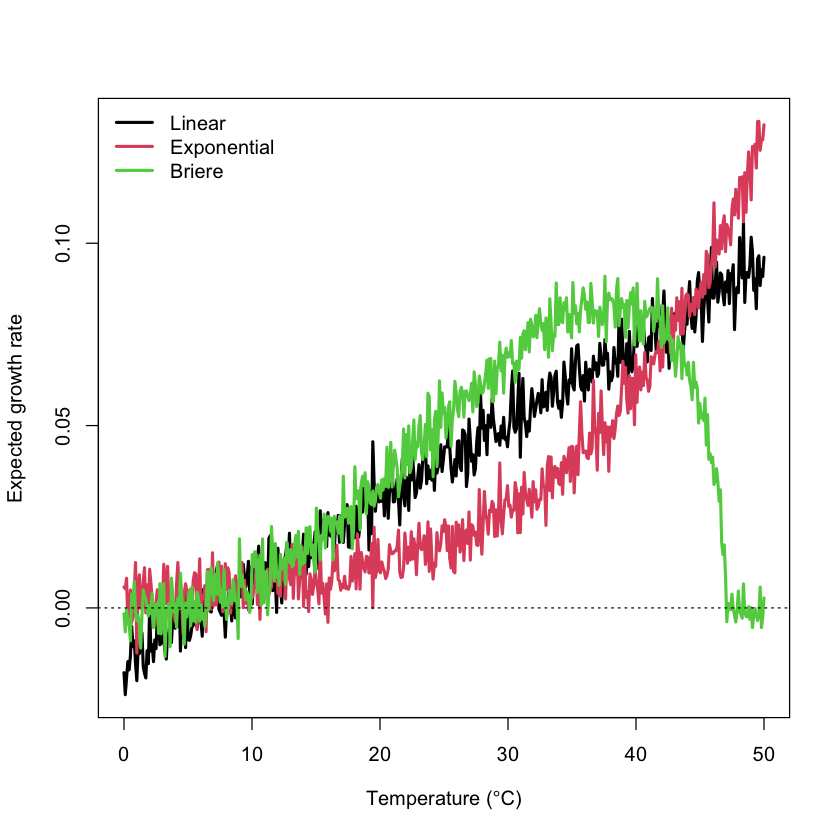

In [3]:
# Temperature range used only for illustration
T_grid <- seq(0, 50, length.out = 500)

# Illustrative parameter configurations
parameters <- list(
  linear      = c(pr_a = 0.0022, pr_b = -0.015, sigma = 0.005),
  exponential = c(pr_a = 0.012, pr_b = 0.08, pr_c = 20, sigma = 0.005),
  briere      = c(pr_a = 2.2e-5, pr_b = 5, pr_c = 47, sigma = 0.005)
)

# Calculate the expected response under each model
predictions <- sapply(names(models), function(model_name) {
    models[[model_name]]$sim(
      T = T_grid,
      param = parameters[[model_name]]
    )
  })

colnames(predictions) <- c("Linear", "Exponential", "Briere")

# Plot
par(bg = "white")

matplot(T_grid, predictions,
  type = "l", lty = 1, lwd = 2.5, ylim = range(c(0, predictions), finite = TRUE),
  xlab = expression("Temperature (" * degree * "C)"), ylab = "Expected growth rate")

abline(h = 0, lty = 3)

legend("topleft",
  legend = colnames(predictions), col = seq_len(ncol(predictions)),
  lty = 1, lwd = 2.5, bty = "n")


## Implementing an ABC–SMC algorithm

This plot illustrates why a stochastic model cannot be represented by a single expected curve. Even when the model and its parameters remain unchanged, repeated simulations can produce different outcomes.

Once we can simulate from the model, however, we can compare each simulated dataset with the observations. Let us denote the observations by $\delta$ and a simulated dataset by $\delta^*$. We then define a distance

$$
d(\delta^*,\delta),
$$

which measures how different the simulated and observed datasets are.

For this example, we use the root mean squared error:

$$
d(\delta^*,\delta) = \sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\delta_i^*-\delta_i
\right)^2
}.
$$

A small distance indicates that the simulation resembles the observations, whereas a large distance indicates poor agreement.

We must also choose a tolerance, $\epsilon$, describing how close a simulation must be to the observations. A proposed model and parameter configuration is accepted when

$$
d(\delta^*,\delta)\leq\epsilon.
$$

This simple rule replaces the likelihood evaluation.


### Rejection ABC

The most direct implementation is an ABC rejection sampler. For each proposal, we:

1. sample a model from $P(M)$;
2. sample its parameters from $P(\theta_M\mid M)$;
3. simulate a dataset $\delta^*$ from that model;
4. calculate $d(\delta^*,\delta)$;
5. retain the proposal if the distance is no greater than $\epsilon$.

The process is repeated until we have collected the desired number of accepted particles.

The accepted particles approximate the distribution

$
P_\epsilon(M,\theta_M\mid\delta)
\propto
P(M)
P(\theta_M\mid M)
P\left[
d(\delta^*,\delta)\leq\epsilon
\mid
M,\theta_M
\right].
$

The last term,

$
P\left[
d(\delta^*,\delta)\leq\epsilon
\mid
M,\theta_M
\right],
$

is the probability that the model produces a simulation sufficiently close to the observations. 

If $\epsilon$ is sufficiently small, the ABC distribution provides a good approximation to the true posterior distribution:

$
P_\epsilon(M,\theta_M\mid\delta)
\longrightarrow
P(M,\theta_M\mid\delta)
\qquad
\text{as }\epsilon\rightarrow0,
$

provided that the comparison uses the full data or sufficient summary statistics.

We do not calculate $P_\epsilon(M,\theta_M\mid\delta)$ directly. Instead, we approximate it by repeatedly simulating from the models and retaining the proposals that satisfy the tolerance.

A large tolerance accepts many simulations, including some that are only weakly similar to the observations. A small tolerance gives a closer approximation to the posterior distribution, but accepted simulations become increasingly rare.

Jumping immediately to a very small tolerance would therefore reproduce the same problem we encountered with ordinary rejection sampling: almost every proposal would be discarded.


### Moving through a sequence of tolerances

Like the likelihood-tempered SMC method introduced previously, ABC–SMC avoids an abrupt jump to the final target by moving through a sequence of intermediate populations. Here, however, the progression is controlled by a decreasing sequence of tolerances:

$
\epsilon_1 > \epsilon_2 > \cdots > \epsilon_S.
$

At the first tolerance, $\epsilon_1$, particles are generated directly from the joint model and parameter priors, just as in rejection ABC.

This initial tolerance is deliberately generous, allowing us to obtain the first particle population without rejecting almost every proposal.

At each subsequent tolerance level, we use the preceding population to guide the proposals. To generate a new particle, we:

1. select a particle from the preceding population according to its weight;
2. retain its model and perturb its parameter values;
3. simulate a new model realisation using the perturbed parameters;
4. accept the proposal if its distance from the observations is no greater than the new tolerance.

These steps are repeated until a complete new population of accepted particles has been obtained.

As the tolerance decreases, the particle population gradually moves towards model and parameter configurations that produce simulations increasingly similar to the observations.


### Weighting the accepted particles

Particles in the first population are drawn directly from the joint prior. At subsequent iterations, proposals are generated by selecting and perturbing particles from the preceding population. If however proposals are generated only by selecting particles from the preceding population, a model that disappears completely cannot return. To avoid this irreversible loss, we occasionally draw a completely new model and parameter configuration from the joint prior. We call this a **global proposal**.

Regardless of how the particles are generated, importance weights are assigned to each to facilitate more uniform exploration of the parameter space during resamplings of the generations.

In the first generation, the particles are assigned equal weights. At later generations, the weight of particle $i$ in population $s$ is

$$
w_s^{i}
\propto
\frac{
P(M_i)P(\theta_i\mid M_i)
}{
q_s(M_i,\theta_i)
},
$$

where $q_s(M_i,\theta_i)$ is the probability density under the proposal mechanism used at generation $s$.

If the probability of making a global proposal is $g$, the proposal density is

$$
q_s(M,\theta) = gP(M)P(\theta\mid M) + (1-g)
\sum_{j:M_j=M}
w_{s-1}^{j}
K_M(\theta\mid\theta_j),
$$

where $K_M(\theta\mid\theta_j)$ is the perturbation kernel for model $M$.

If $g=1$, every proposal is drawn directly from the joint prior:

$$
q_s(M,\theta) = P(M)P(\theta\mid M).
$$

The importance weight therefore becomes

$$
w_s
\propto
\frac{
P(M)P(\theta\mid M)
}{
P(M)P(\theta\mid M)
} = 1.
$$

If $g=0$, every proposal is generated by selecting and perturbing a particle from the preceding population:

$$
q_s(M,\theta) = \sum_{j:M_j=M}
w_{s-1}^{j}
K_M(\theta\mid\theta_j).
$$

The new particles must then be reweighted because this proposal distribution generally differs from the joint prior:

$$
w_s^{i}
\propto
\frac{
P(M_i)P(\theta_i\mid M_i)
}{
\displaystyle
\sum_{j=M_i}
w_{s-1}^{j}
K_{M_i}(\theta_i\mid\theta_j)
}.
$$

Values between zero and one combine both behaviours: local proposals improve efficiency, while occasional global proposals allow lost models and unexplored parameter regions to re-enter the population.


### Estimating model probabilities

Once the final particle population has been obtained, the posterior probability of a model is estimated by summing the weights of all particles belonging to that model:

$$
P(M=m\mid\delta)
\approx
\sum_{i:M_i=m}w_i.
$$

Similarly, the weighted parameter values within each model approximate its parameter posterior distribution.

In [27]:
abc.smc <- function(models,
                    T,
                    rho,
                    tolerances,
                    n_particles = 1000,
                    model_prior = NULL,
                    summary.statistic = identity,
                    distance = function(simulated, observed) {
                      sqrt(mean((simulated - observed)^2))
                    },
                    global_proposal_probability = 0.1,
                    max_attempts = 1e7,
                    verbose = TRUE) {
  model_names <- names(models)
  n_models <- length(models)
  n_stages <- length(tolerances)

  # Equal model probabilities unless otherwise specified
  if (is.null(model_prior)) {
    model_prior <- rep(1 / n_models, n_models)
    names(model_prior) <- model_names
  } else {
    model_prior <- model_prior[model_names]
    model_prior <- model_prior / sum(model_prior)
  }

  observed_summary <- summary.statistic(rho)

  # ----------------------------------------------------------
  # Helper functions
  # ----------------------------------------------------------

  log.sum.exp <- function(x) {
    if (length(x) == 0 || all(!is.finite(x))) {
      return(-Inf)
    }

    largest <- max(x)
    largest + log(sum(exp(x - largest)))
  }

  normalise.log.weights <- function(log_weights) {
    largest <- max(log_weights)

    if (!is.finite(largest)) {
      stop("All particle weights are zero.")
    }

    weights <- exp(log_weights - largest)
    weights / sum(weights)
  }

  log.kernel.density <- function(theta, centre, sd) {
    sum(dnorm(theta, mean = centre, sd = sd, log = TRUE))
  }

  # ----------------------------------------------------------
  # Storage
  # ----------------------------------------------------------

  population_history <- vector("list", n_stages)

  model_history <- vector("list", n_stages)

  diagnostics <- vector("list", n_stages)

  previous_population <- NULL

  # ----------------------------------------------------------
  # Move through the ABC tolerance sequence
  # ----------------------------------------------------------

  for (stage in seq_len(n_stages)) {
    epsilon <- tolerances[stage]

    particle_model <- integer(n_particles)
    particle_theta <- vector("list", n_particles)

    particle_distance <- numeric(n_particles)
    particle_log_weight <- numeric(n_particles)

    accepted <- 0
    attempts <- 0

    while (accepted < n_particles) {
      attempts <- attempts + 1

      if (attempts > max_attempts) {
        stop("Maximum number of proposals reached at tolerance ",
             epsilon,
             ". Try increasing the tolerance.")
      }

      # ------------------------------------------------------
      # First population: draw directly from the joint prior
      # ------------------------------------------------------

      if (stage == 1) {
        proposed_model <- sample.int(n_models, size = 1, prob = model_prior)
        proposed_theta <- models[[proposed_model]]$sample.prior()
      } else {
        # ----------------------------------------------------
        # Later populations use a mixture proposal:
        #
        # 1. draw globally from the joint prior; or
        # 2. perturb a particle from the previous population.
        # ----------------------------------------------------

        if (runif(1) < global_proposal_probability) {
          # ------------------------------------------------------------------
          # Draw a new model and parameter configuration from the joint prior. 
          # ------------------------------------------------------------------
          proposed_model <- sample.int(n_models, size = 1, prob = model_prior)
          proposed_theta <- models[[proposed_model]]$sample.prior()
        } else {
          # ------------------------------------------------------------------
          # Draw a model and parameter configuration from the previous 
          # population and perturb model parameters.
          # ------------------------------------------------------------------
          ancestor <- sample.int(n_particles, size = 1, prob = previous_population$weight)
          proposed_model <- previous_population$model[ancestor]

          ancestor_theta <- previous_population$theta[[ancestor]]
          sd <- models[[proposed_model]]$proposal.sd
          proposed_theta <- ancestor_theta + rnorm(length(ancestor_theta), mean = 0, sd = sd)

          names(proposed_theta) <- names(ancestor_theta)
        }
      }

      proposed_log_prior <- models[[proposed_model]]$log.prior(proposed_theta)

      # Proposals outside the prior are rejected immediately
      if (!is.finite(proposed_log_prior)) {
        next
      }

      # ------------------------------------------------------
      # Simulate a dataset and calculate its distance
      # ------------------------------------------------------

      simulated <- tryCatch(
        models[[proposed_model]]$sim(T, proposed_theta),
        error = function(e) NULL
      )

      if (is.null(simulated) ||
          length(simulated) != length(rho) ||
          any(!is.finite(simulated))) {
        next
      }

      simulated_summary <- summary.statistic(simulated)

      proposed_distance <- distance(simulated_summary, observed_summary)

      if (length(proposed_distance) != 1 ||
          !is.finite(proposed_distance) ||
          proposed_distance > epsilon) {
        next
      }

      # ------------------------------------------------------
      # Accept the particle
      # ------------------------------------------------------

      accepted <- accepted + 1

      particle_model[accepted] <- proposed_model

      particle_theta[[accepted]] <- proposed_theta

      particle_distance[accepted] <- proposed_distance

      # ------------------------------------------------------
      # Importance weight
      # ------------------------------------------------------

      if (stage == 1) {
        # The proposal is exactly the joint prior
        particle_log_weight[accepted] <- 0
      } else {
        # Target density:
        #
        # P(M) P(theta | M)
        #
        # The ABC acceptance probability is represented by
        # the condition distance <= epsilon.

        log_target <-
          log(model_prior[proposed_model]) +
          proposed_log_prior

        # Global component of the proposal:
        #
        # g P(M) P(theta | M)

        if (global_proposal_probability > 0) {
          log_global_proposal <- log(global_proposal_probability) + 
                                 log(model_prior[proposed_model]) + 
                                 proposed_log_prior
        } else {
          log_global_proposal <- -Inf
        }

        # Local perturbation component:
        #
        # (1-g) sum_j w_j K(theta | theta_j)
        #
        # The sum only includes particles belonging to
        # the proposed model.

        same_model <- which(previous_population$model == proposed_model)

        if (global_proposal_probability < 1 && length(same_model) > 0) {
          sd <- models[[proposed_model]]$proposal.sd

          log_kernel_terms <- vapply(same_model, function(j) {
              log(previous_population$weight[j]) +
              log.kernel.density(theta = proposed_theta,
                                 centre = previous_population$theta[[j]],
                                 sd = sd)
            },
            numeric(1)
          )

          log_local_proposal <- log1p(-global_proposal_probability) + log.sum.exp(log_kernel_terms)
        } else {
          log_local_proposal <- -Inf
        }

        # The complete proposal is a mixture of the
        # global and local proposal densities.

        log_proposal <- log.sum.exp(c(log_global_proposal, log_local_proposal))

        particle_log_weight[accepted] <- log_target - log_proposal
      }
    }

    particle_weight <- normalise.log.weights(particle_log_weight)

    # --------------------------------------------------------
    # Store the completed population
    # --------------------------------------------------------

    current_population <- list(
      tolerance = epsilon,
      model = particle_model,
      theta = lapply(particle_theta, identity),
      distance = particle_distance,
      weight = particle_weight
    )

    population_history[[stage]] <- current_population

    model_history[[stage]] <- setNames(
      vapply(seq_len(n_models), function(m) { 
        sum(particle_weight[particle_model == m]) 
        },
        numeric(1)
      ),
      model_names
    )

    diagnostics[[stage]] <- data.frame(
      stage = stage,
      tolerance = epsilon,
      attempts = attempts,
      accepted = n_particles,
      acceptance_rate = n_particles / attempts
    )

    if (verbose) {
      message(
        "Stage ", stage,
        ": tolerance = ", signif(epsilon, 4),
        ", attempts = ", attempts,
        ", acceptance rate = ",
        signif(n_particles / attempts, 4)
      )
    }

    previous_population <- current_population
  }

  # ----------------------------------------------------------
  # Convert the final population into a data frame
  # ----------------------------------------------------------

  parameter_names <- unique(unlist(lapply(particle_theta, names)))

  particles <- data.frame(
    model = model_names[particle_model],
    weight = particle_weight,
    distance = particle_distance,
    stringsAsFactors = FALSE
  )

  particles$param <- I(particle_theta)

  for (parameter in parameter_names) {
    particles[[parameter]] <- vapply(particle_theta, function(theta) {
        if (parameter %in% names(theta)) {
          unname(theta[parameter])
        } else {
          NA_real_
        }
      },
      numeric(1)
    )
  }

  model_probability <- vapply(seq_len(n_models), function(m) {
      sum(particle_weight[particle_model == m])
    },
    numeric(1)
  )

  names(model_probability) <- model_names

  model_history <- data.frame(
    tolerance = tolerances,
    do.call(rbind, model_history),
    check.names = FALSE
  )

  diagnostics <- do.call(rbind, diagnostics)

  rownames(diagnostics) <- NULL

  structure(
    list(
      particles = particles,
      populations = population_history,
      model_probability = model_probability,
      model_history = model_history,
      diagnostics = diagnostics,
      tolerances = tolerances,
      model_prior = model_prior
    ),
    class = "abc_smc_model_selection"
  )
}

In [28]:
abc_fit <- abc.smc(models = models,
                   T = d$T.C,
                   rho = d$rate.per.minute,
                   tolerances = exp(seq(log(0.08), log(0.004), length.out = 25)),
                   n_particles = 1000,
                   global_proposal_probability = 0.1)

Stage 1: tolerance = 0.08, attempts = 1446, acceptance rate = 0.6916

Stage 2: tolerance = 0.07061, attempts = 1240, acceptance rate = 0.8065

Stage 3: tolerance = 0.06233, attempts = 1236, acceptance rate = 0.8091

Stage 4: tolerance = 0.05501, attempts = 1326, acceptance rate = 0.7541

Stage 5: tolerance = 0.04856, attempts = 1386, acceptance rate = 0.7215

Stage 6: tolerance = 0.04286, attempts = 1387, acceptance rate = 0.721

Stage 7: tolerance = 0.03783, attempts = 1509, acceptance rate = 0.6627

Stage 8: tolerance = 0.03339, attempts = 1571, acceptance rate = 0.6365

Stage 9: tolerance = 0.02947, attempts = 1361, acceptance rate = 0.7348

Stage 10: tolerance = 0.02601, attempts = 1664, acceptance rate = 0.601

Stage 11: tolerance = 0.02296, attempts = 2151, acceptance rate = 0.4649

Stage 12: tolerance = 0.02027, attempts = 1880, acceptance rate = 0.5319

Stage 13: tolerance = 0.01789, attempts = 2157, acceptance rate = 0.4636

Stage 14: tolerance = 0.01579, attempts = 2336, acce

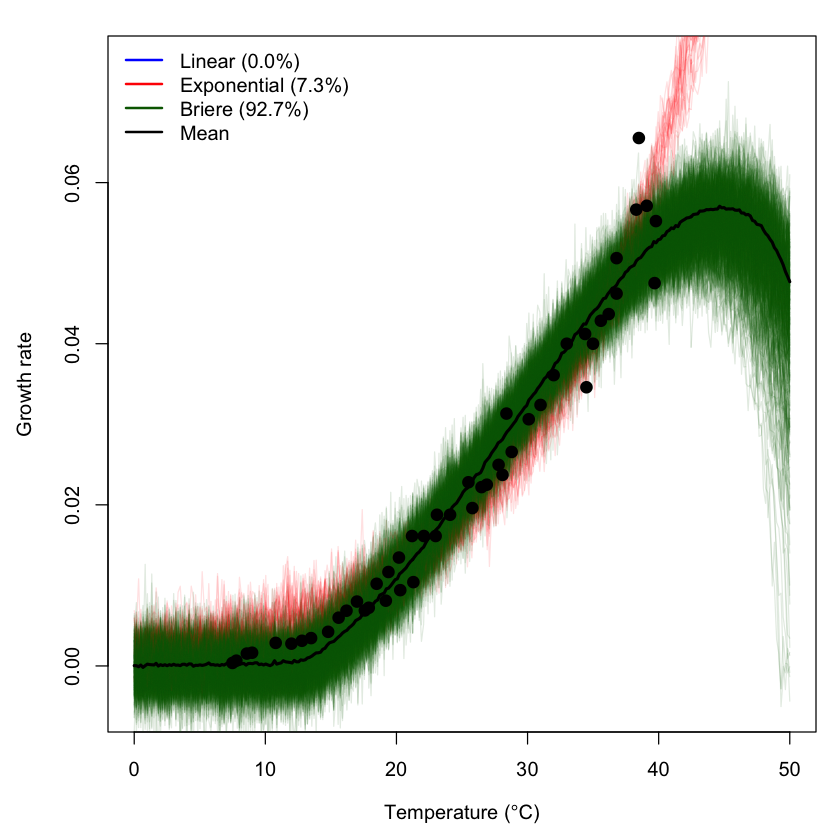

In [60]:
model_colours <- c(
  linear      = "blue",
  exponential = "red",
  briere      = "darkgreen"
)

T_grid <- seq(0, 50, length.out = 300)

# Use posterior weights when sampling particles
particle_index <- sample(
  seq_len(nrow(abc_fit$particles)),
  size = min(500, nrow(abc_fit$particles)),
  replace = FALSE,
  prob = abc_fit$particles$weight
)

sim_matrix <- matrix(
  NA_real_,
  nrow = length(particle_index),
  ncol = length(T_grid)
)

particle_model <- character(length(particle_index))

for (k in seq_along(particle_index)) {
  i <- particle_index[k]

  model_name <- abc_fit$particles$model[i]
  param <- abc_fit$particles$param[[i]]

  particle_model[k] <- model_name

  sim_matrix[k, ] <- models[[model_name]]$sim(T_grid, param)
}

mean_simulated <- colMeans(sim_matrix, na.rm = TRUE)

par(bg = "white", mar = c(4.5, 4.5, 1.5, 1))

plot(d$T.C, d$rate.per.minute,
  xlim = range(T_grid), ylim = c(-0.005,0.075), type = "n",
  ylab = "Growth rate", xlab = expression("Temperature (" * degree * "C)"))

for (k in seq_len(nrow(sim_matrix))) {
  lines(T_grid, sim_matrix[k, ],
        col = adjustcolor(
          model_colours[particle_model[k]],
          alpha.f = 0.12
        ),
        lwd = 1)
}

lines(T_grid, mean_simulated, col = "black", lwd = 2.5)

points(d$T.C, d$rate.per.minute, pch = 16, cex = 1.4)

model_probabilities <- abc_fit$model_probability

legend("topleft", legend = c(sprintf(
    "%s (%.1f%%)",
    c("Linear", "Exponential", "Briere"),
    100 * model_probabilities[c("linear", "exponential", "briere")]
  ), "Mean"),
  col = c(model_colours, "black"), lty = 1, lwd = 2, bty = "n")

This concludes the first chapter on model and parameter inference. Of course, there is much more to discuss, but we will save those topics for a more advanced course.

We now turn to the many creative and exciting ways in which hypotheses can be generated and translated into mathematical models.